This dataset was published by C. Zhang, Q. Lin, C. Yang, Y. Kong, Z. Yu, and K. Liao and contains HTE data with 1H NMR yields for 47,000 amide coupling reactions using 96 different reaction conditions.

Reference: Chem. Sci. 2025, 16, 11809-11822.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdChemReactions
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import colorsys
from scipy.stats import ks_2samp
from statsmodels.stats.multitest import multipletests


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
hist_color = "#dfdfdf"
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14  # Legend titles
})

Load the data

In [2]:
data = pd.read_csv("amide_raw_experimental_data.csv",index_col=0, header=0)
# Ensure the SMILES strings are all canonical
for compound_class in ["sub_1_smiles","sub_2_smiles","product_smiles"]:
    data[compound_class] = data[compound_class].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x),canonical=True))
data.head()

,idx,condition_id,sub_1_smiles,sub_2_smiles,product_smiles,Activation_ID,Additive_ID,Base_ID,solvent_id,yield,yield_clf,name0,archive,train_or_test,y_pred,condition_SMILES,text
0,15635,84,Cc1ccc(N)nc1,O=C(O)c1cc2ccccc2s1,Cc1ccc(NC(=O)c2cc3ccccc3s2)nc1,R2,A5,B1,S1,0.431730,1,22003-30-1-PL26-LC1-C84,2208_1,train,0.385567,CC(C)N=C=NC(C)C.C1=CC2=C(N=C1)N(N=N2)O.CN(C)C=O,Cc1ccc(N)nc1.O=C(O)c1cc2ccccc2s1.CC(C)N=C=NC(C...
1,4731,28,NCc1ccc(F)cc1F,O=C(O)c1ccco1,O=C(NCc1ccc(F)cc1F)c1ccco1,R8,A7,B7,S1,0.720284,1,22003-14-1-PL26-LC1-C28,2208_1,train,0.690787,CCN=C=NCCCN(C)C.Cl.C1=CC=C2C(=C1)C(=O)N(C2=O)O...,NCc1ccc(F)cc1F.O=C(O)c1ccco1.CCN=C=NCCCN(C)C.C...
2,22762,12,NCc1ccc(Cl)cc1,O=C(O)c1cccc(-c2ccccc2)c1,O=C(NCc1ccc(Cl)cc1)c1cccc(-c2ccccc2)c1,R19,A1,B7,S1,0.510634,1,22003-33-1-PL24-LC1-C12,2209_3,train,0.423631,[B-](F)(F)(F)F.CN(C)C(=[N+](C)C)ON1C(=O)CCC1=O...,NCc1ccc(Cl)cc1.O=C(O)c1cccc(-c2ccccc2)c1.[B-](...
3,7892,21,COc1ccc(CN)cc1,CC(C(=O)O)c1ccc(-c2ccccc2)c(F)c1,COc1ccc(CNC(=O)C(C)c2ccc(-c3ccccc3)c(F)c2)cc1,R28,A4,B7,S1,0.812231,1,22003-18-1-PL19-LC1-C21,2208_1,train,0.768770,CN(C)C(=[N+](C)C)ON1C2=CC=CC=C2N=N1.F[P-](F)(F...,COc1ccc(CN)cc1.CC(C(=O)O)c1ccc(-c2ccccc2)c(F)c...
4,17450,75,COc1ccc(N)cn1,O=C(O)c1cccc(-c2ccccc2)c1,COc1ccc(NC(=O)c2cccc(-c3ccccc3)c2)cn1,R25,A1,B7,S1,0.872795,1,22003-31-1-PL9-LC1-C75,2208_1,train,0.829112,[B-](F)(F)(F)F.CN(C)C(=[N+](C)C)ON1C(=O)C2=CC=...,COc1ccc(N)cn1.O=C(O)c1cccc(-c2ccccc2)c1.[B-](F...


During our investigation, we found that one of the products in the dataset is not an amide. In light of the structures of the starting materials associated with this product, this is likely due to a typo leading to an additional carbon atom in the product.  We therefore changed the structure of this compound to the expected product of the amide coupling.

Non-amide product in the dataset:


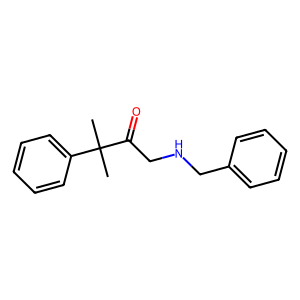

The above shown compound 'CC(C)(C(=O)CNCc1ccccc1)c1ccccc1' is in the list of products in the dataset.


In [3]:
non_amide_prod = "CC(C)(C(=O)CNCc1ccccc1)c1ccccc1"

print("Non-amide product in the dataset:")
depiction = Draw.MolToImage(Chem.MolFromSmiles(non_amide_prod))
display(depiction)

# confirm that it is actually in the dataset
if non_amide_prod in data["product_smiles"].to_list():
    print(f"The above shown compound '{non_amide_prod}' is in the list of products in the dataset.")
else:
    print(f"The above shown compound '{non_amide_prod}' is not in the dataset.")

In [4]:
# Find the starting materials associated with this product
data_non_amide = data[data["product_smiles"] == non_amide_prod]
print("Starting materials associated with this product:")
print(f'Amines: {data_non_amide["sub_1_smiles"].unique()}')
print(f'Acids: {data_non_amide["sub_2_smiles"].unique()}')

# Double check that this substrate combination only forms this product
prod_check = list(data[(data["sub_1_smiles"] == 'NCc1ccccc1') & (data["sub_2_smiles"] == 'CC(C)(C(=O)O)c1ccccc1')]["product_smiles"].unique())
print("Products associated with this substrate combination:", prod_check)


Starting materials associated with this product:
Amines: ['NCc1ccccc1']
Acids: ['CC(C)(C(=O)O)c1ccccc1']
Products associated with this substrate combination: ['CC(C)(C(=O)CNCc1ccccc1)c1ccccc1']


Reaction leading to the non-amide product:


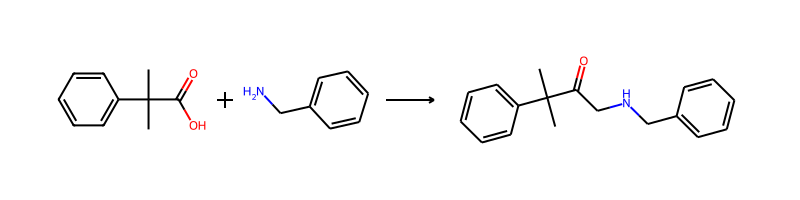

In [5]:
# Draw the reaction
reaction_smiles = f"CC(C)(C(=O)O)c1ccccc1.NCc1ccccc1>>{non_amide_prod}"
rxn = rdChemReactions.ReactionFromSmarts(reaction_smiles, useSmiles=True)
print("Reaction leading to the non-amide product:")
Draw.ReactionToImage(rxn)

Modification of the structure in the dataset:


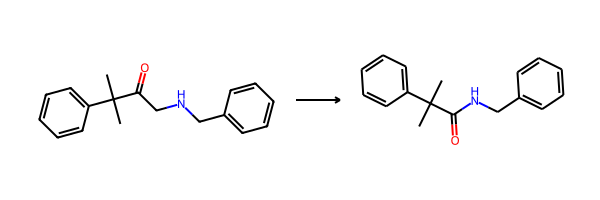

The compound 'CC(C)(C(=O)CNCc1ccccc1)c1ccccc1' is not in the dataset anymore.
It was replaced with the compound 'CC(C)(C(=O)NCc1ccccc1)c1ccccc1'.


In [6]:
# Replace the product structure
print("Modification of the structure in the dataset:")
updated_smiles = Chem.MolToSmiles(Chem.MolFromSmiles("CC(C)(C(=O)NCc1ccccc1)c1ccccc1"),canonical=True)
data["product_smiles"] = data["product_smiles"].replace(non_amide_prod, updated_smiles)
rxn = rdChemReactions.ReactionFromSmarts(f"{non_amide_prod}>>{updated_smiles}", useSmiles=True)
display(Draw.ReactionToImage(rxn))

# confirmation that the replacement worked
if non_amide_prod in data["product_smiles"].to_list():
    print(f"The compound '{non_amide_prod}' is in the list of products in the dataset.")
else:
    print(f"The compound '{non_amide_prod}' is not in the dataset anymore.")
    if updated_smiles in data["product_smiles"].to_list():
        print(f"It was replaced with the compound '{updated_smiles}'.")

In [7]:
# save this processed version of the dataset
data.to_csv("amide_proc_experimental_data.csv",index=True,header=True)

Analyze product counts and the overall number of substrates

In [8]:
product_smiles = data["product_smiles"].unique().tolist()
print(f"There are {len(product_smiles)} different products in the full dataset.")
# convert to canonical smiles and save
product_smiles = [Chem.MolToSmiles(Chem.MolFromSmiles(smiles),canonical=True) for smiles in product_smiles]
pd.DataFrame(product_smiles).to_csv("./Datasets/0_Descriptor_Generation/amide_smiles_products.csv",index=False,header=True)

acid_smiles = data["sub_2_smiles"].unique().tolist()
print(f"There are {len(acid_smiles)} different acids in the full dataset.")
# convert to canonical smiles and save
acid_smiles = [Chem.MolToSmiles(Chem.MolFromSmiles(smiles),canonical=True) for smiles in acid_smiles]

pd.DataFrame(acid_smiles).to_csv("./Datasets/0_Descriptor_Generation/amide_smiles_substrates_acids.csv",index=False,header=True)
amine_smiles = data["sub_1_smiles"].unique().tolist()
print(f"There are {len(amine_smiles)} different amines in the full dataset.")
# convert to canonical smiles and save
amine_smiles = [Chem.MolToSmiles(Chem.MolFromSmiles(smiles),canonical=True) for smiles in amine_smiles]
pd.DataFrame(amine_smiles).to_csv("./Datasets/0_Descriptor_Generation/amide_smiles_substrates_amines.csv",index=False,header=True)


There are 632 different products in the full dataset.
There are 66 different acids in the full dataset.
There are 70 different amines in the full dataset.


Acid substrates:


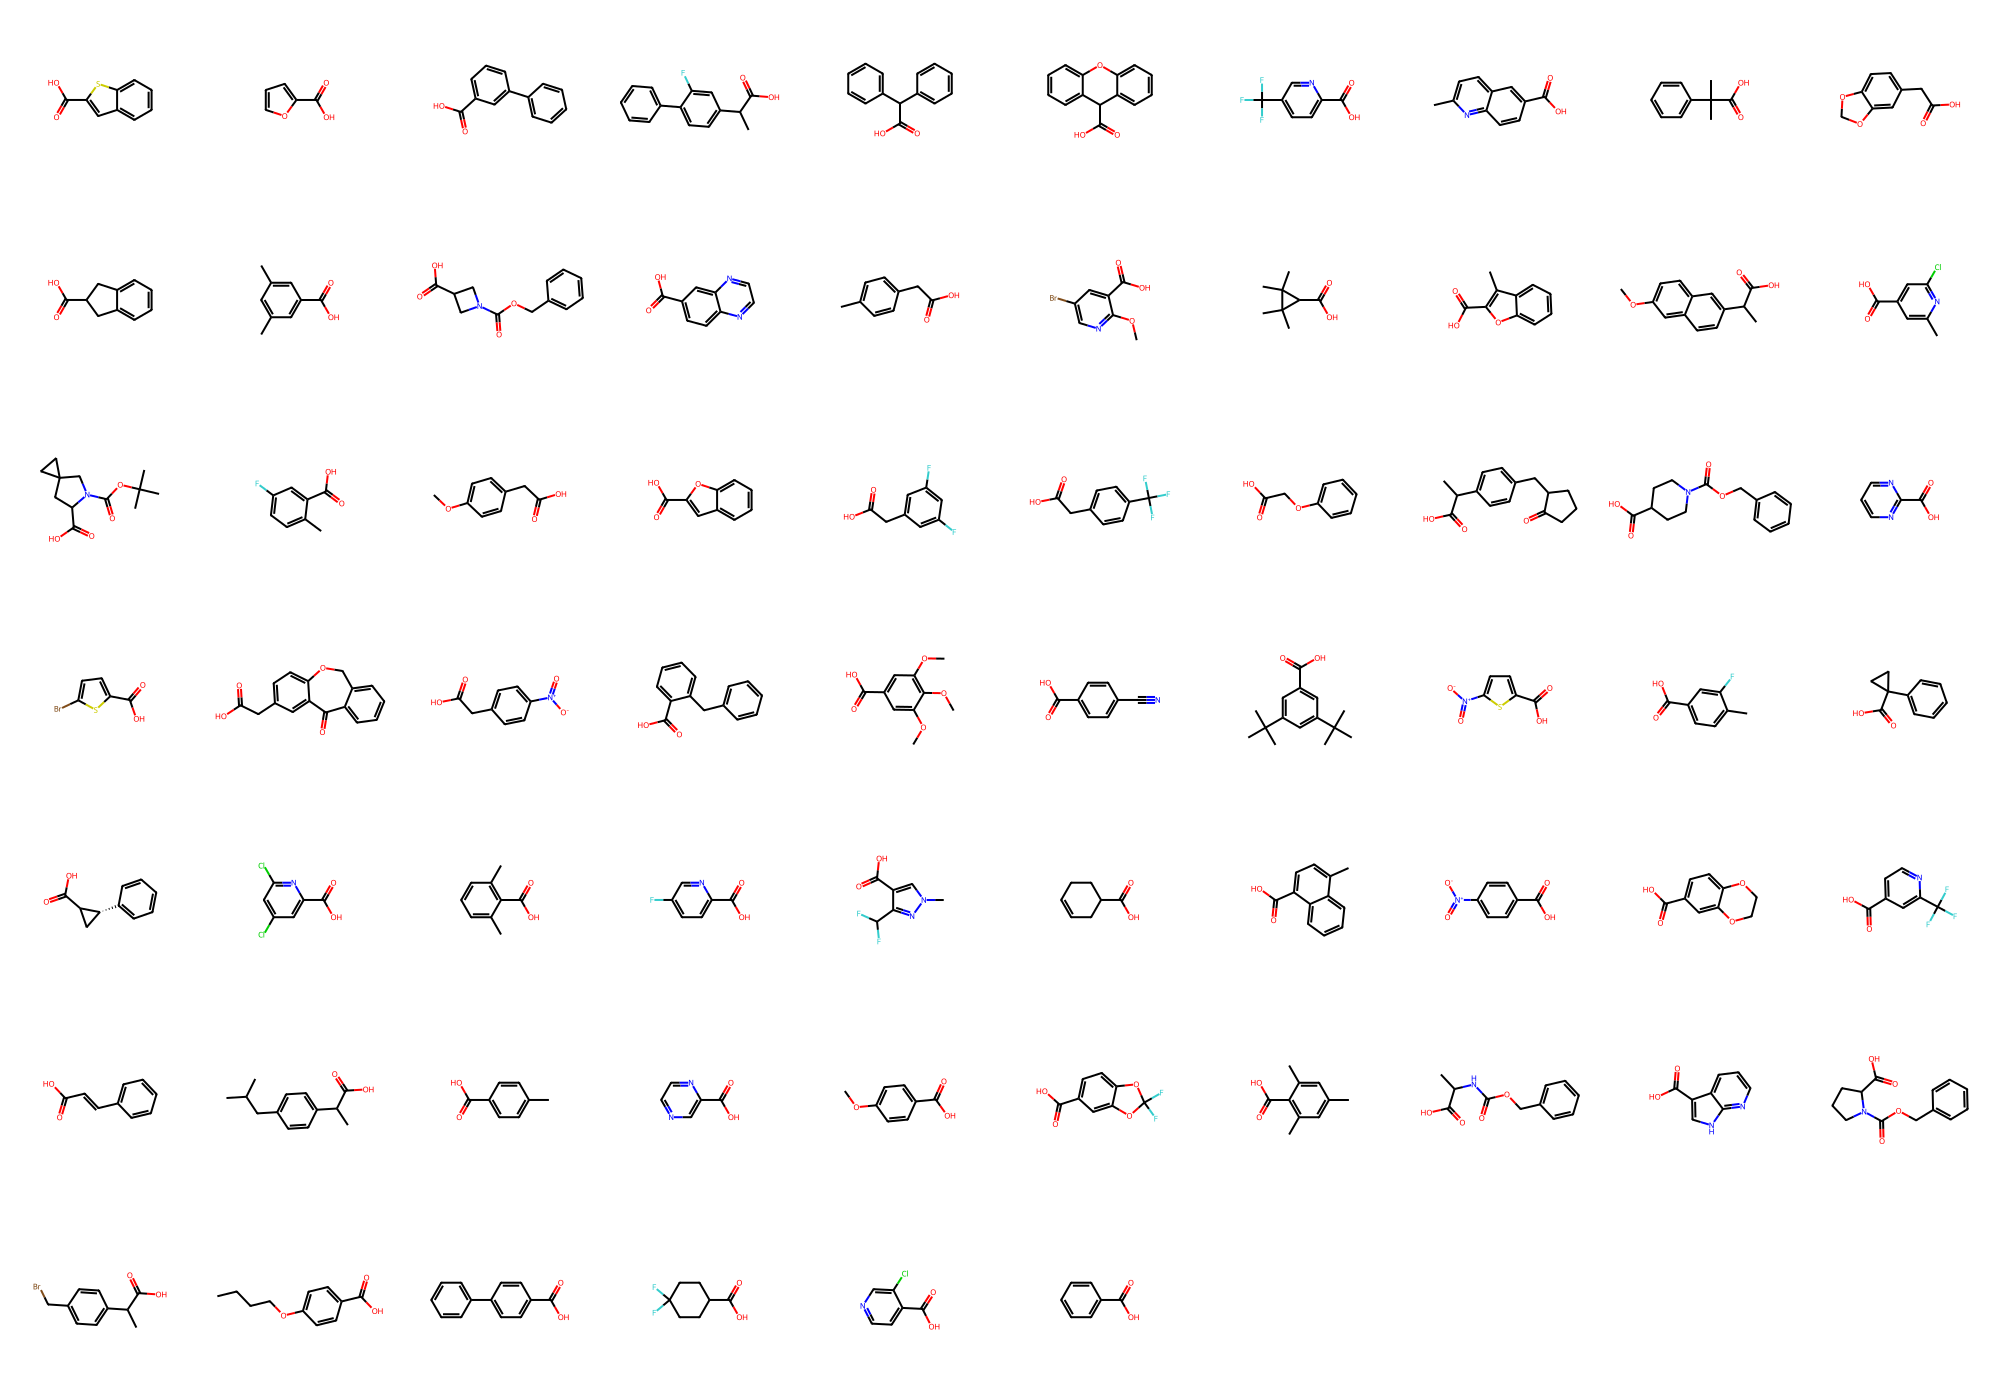

In [9]:
# Visualize the substrates
Draw.IPythonConsole.maxMols = 70
print("Acid substrates:")
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smiles) for smiles in acid_smiles],
    molsPerRow=10,
    subImgSize=(200, 200),
    maxMols=70
    )

Amine substrates:


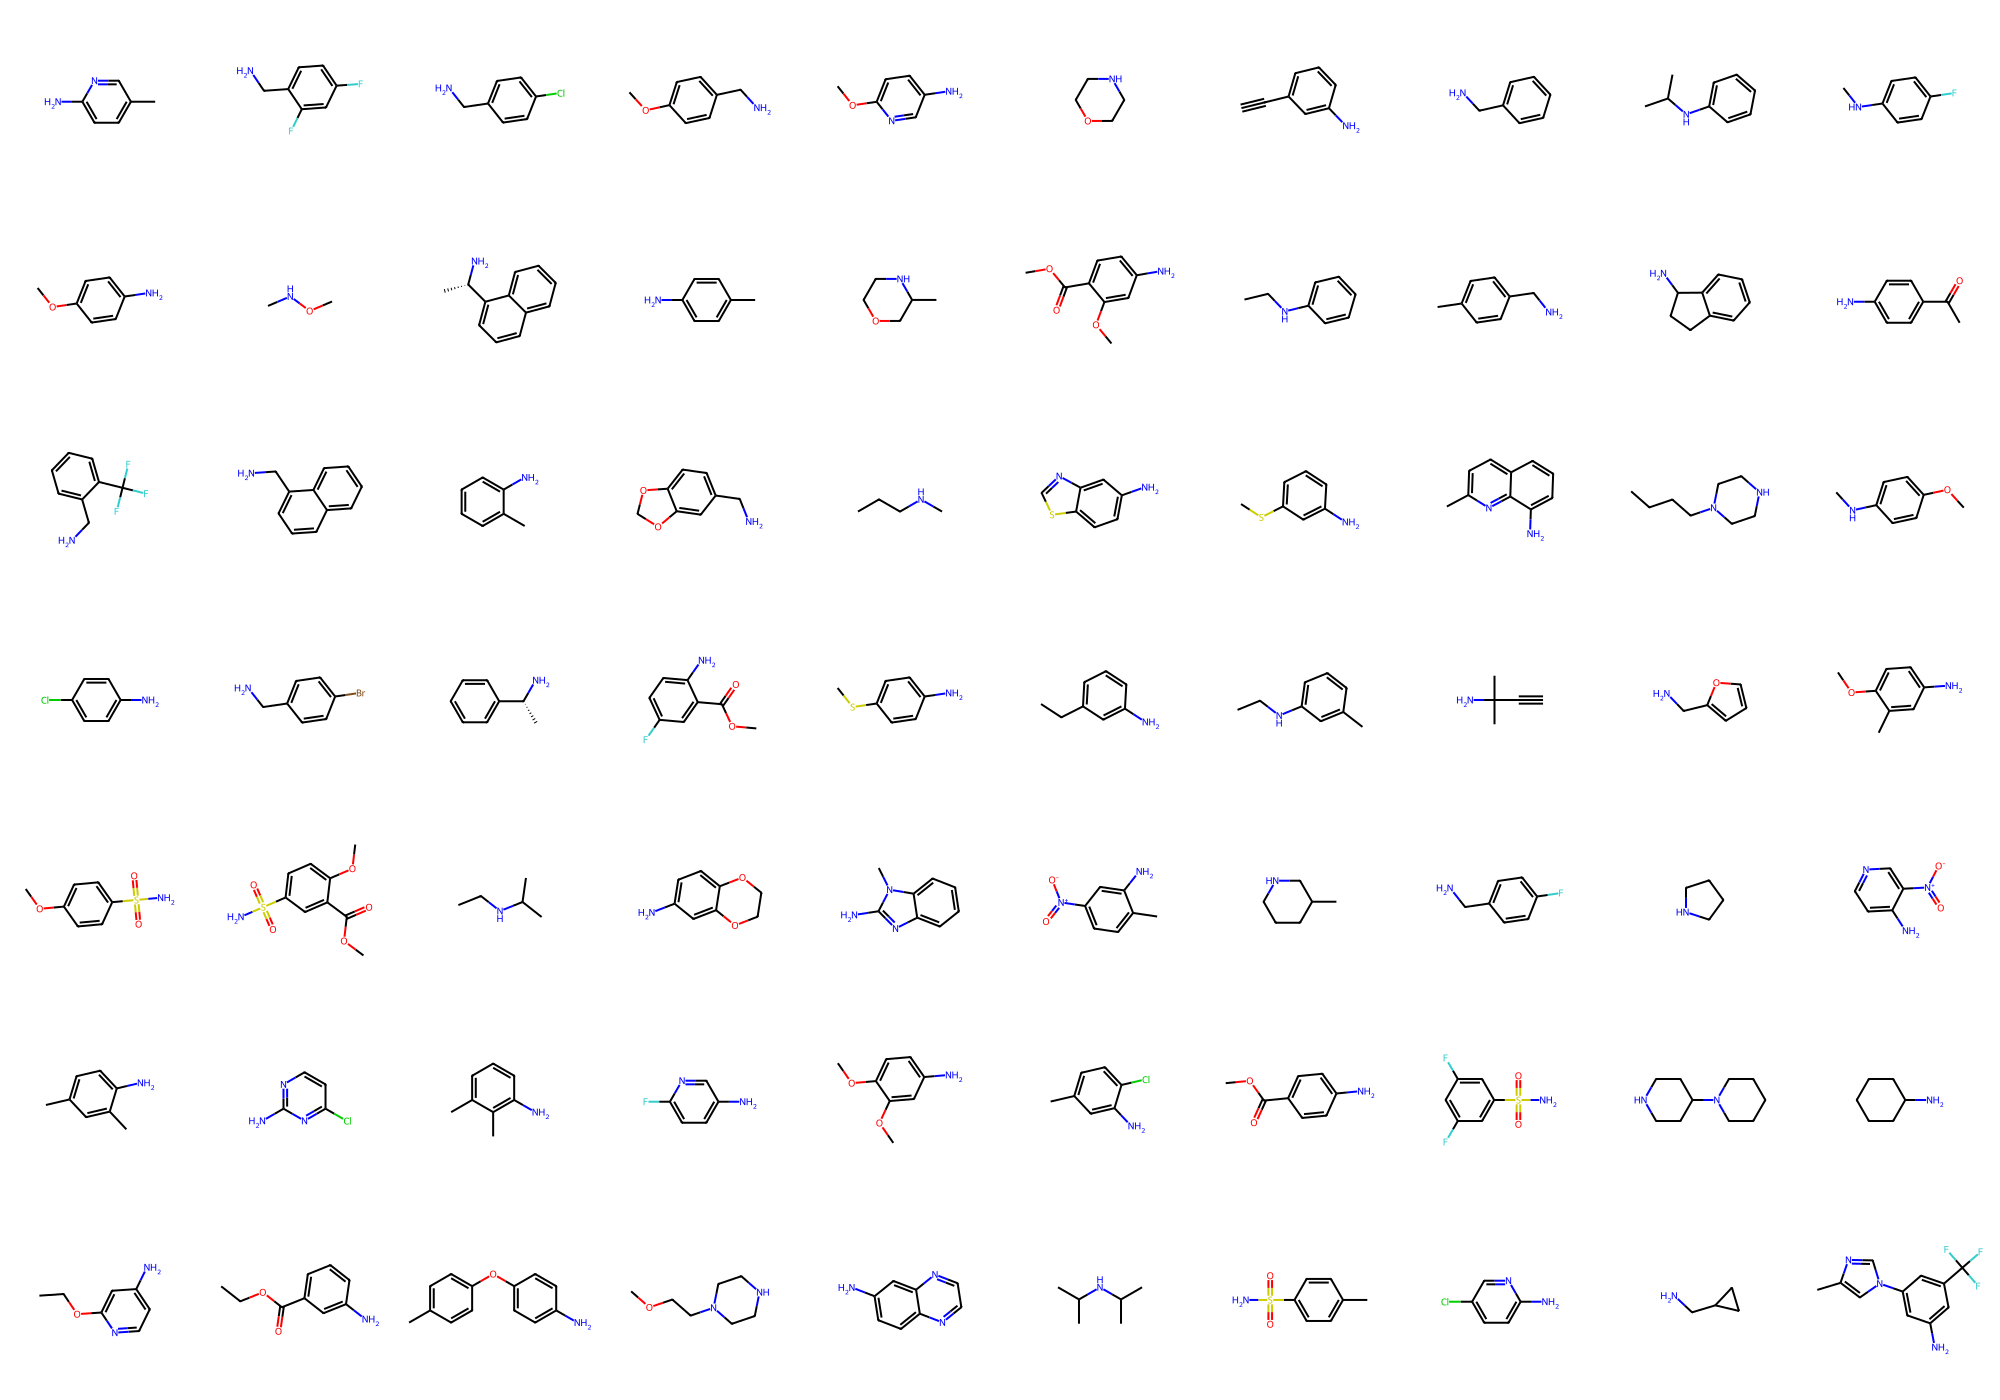

In [10]:
print("Amine substrates:")
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(smiles) for smiles in amine_smiles],
    molsPerRow=10,
    subImgSize=(200, 200),
    maxMols=70
    )

Number of products for the different conditions:


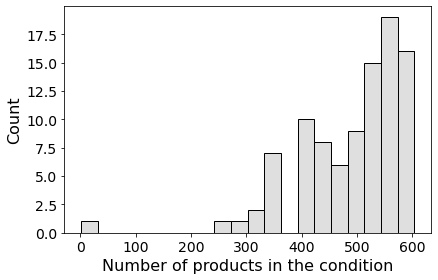

Maximum amount of products for one condition: 604 out of a maximum of 632.



In [11]:
rxn_per_cond = []
for cond in range(1,96):
    count = data["condition_id"].value_counts().get(cond, 0)
    rxn_per_cond.append(count)
print("Number of products for the different conditions:")
plt.figure(figsize=(6, 4))
plt.hist(rxn_per_cond, color=hist_color, bins=20, edgecolor="k")
plt.xlabel("Number of products in the condition")
plt.ylabel("Count")
plt.tick_params(axis='both', which='major')
plt.tight_layout()
plt.show()
print(f"Maximum amount of products for one condition: {max(rxn_per_cond)} out of a maximum of 632.")
print("")


Look at some of the conditions with the most products

In [12]:
# sort the conditions by product count
sorted_by_count = [rxn for rxn in rxn_per_cond]
sorted_by_count.sort(reverse=True)
print("Number of products for the 4 conditions with the most products:")
sorted_by_count[:4]

Number of products for the 4 conditions with the most products:


[604, 600, 599, 591]

In [13]:
# Get the condition IDs for these largest sub-datasets (NOTE: the condition_id's are 1-indexed)
ids_top_cond = [rxn_per_cond.index(prod_numb)+1 for prod_numb in sorted_by_count[:4]]
print(f"Conditions with the most products: {ids_top_cond}")

Conditions with the most products: [23, 20, 37, 13]


In [14]:
print("Number of different substrates used in these conditions:")
for id in ids_top_cond:
    sub_data = data.loc[data["condition_id"] == id]
    print(f'Condition {id}: {len(sub_data["sub_1_smiles"].unique())} amines and {len(sub_data["sub_2_smiles"].unique())} acids')

Number of different substrates used in these conditions:
Condition 23: 69 amines and 66 acids
Condition 20: 70 amines and 66 acids
Condition 37: 69 amines and 66 acids
Condition 13: 69 amines and 65 acids


These condtions all use either all or almost all possible substrates.

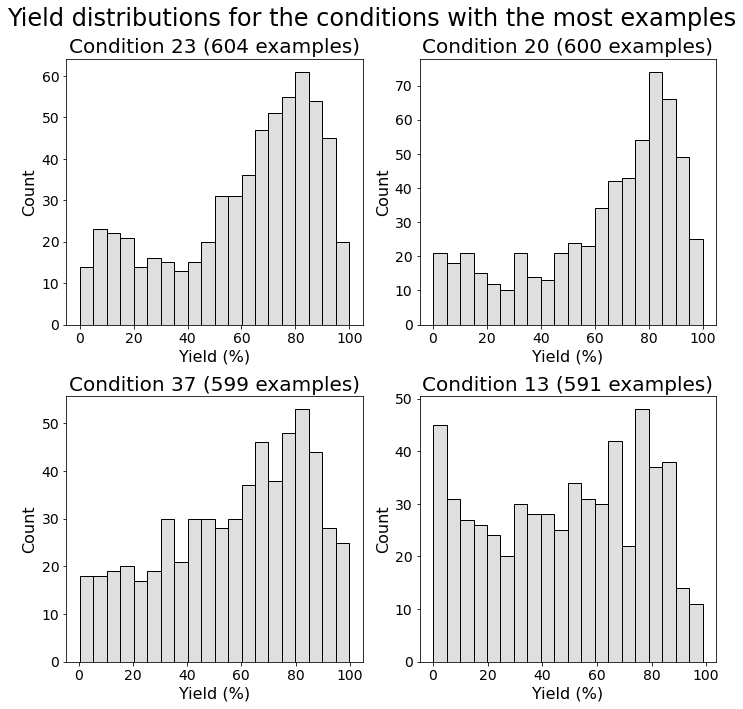

Average yield for these conditions:
Condition 23: 61%
Condition 20: 63%
Condition 37: 58%
Condition 13: 48%
Percentage of low-performing examples for these conditions (<10%):
Condition 23: 6%
Condition 20: 6%
Condition 37: 6%
Condition 13: 13%


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
fig.suptitle("Yield distributions for the conditions with the most examples")
axes = axes.flatten()

for i in range(4):
    sub_data = data.loc[data["condition_id"] == ids_top_cond[i]]
    axes[i].hist(sub_data["yield"]*100, color=hist_color, bins=20, edgecolor="k")
    axes[i].set_xlabel("Yield (%)")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='both', which='major')
    axes[i].set_title(f"Condition {ids_top_cond[i]} ({len(sub_data)} examples)")

plt.tight_layout()
plt.show()

print("Average yield for these conditions:")
for id in ids_top_cond:
    sub_data = data.loc[data["condition_id"] == id]
    print(f'Condition {id}: {round(sub_data["yield"].mean()*100)}%')
print("Percentage of low-performing examples for these conditions (<10%):")
for id in ids_top_cond:
    sub_data = data.loc[data["condition_id"] == id]
    print(f'Condition {id}: {round(len(sub_data[sub_data["yield"] < 0.10])/len(sub_data)*100)}%')

The three conditions with the most examples have a similar data distribution and all exhibit a high overall yield, with condition 20 having the highest average yield and only 4 fewer examples than the conditions with the most examples (condition 23).

Checking for other conditions with many (≥550) examples and an even higher average yield:

In [16]:
conditions_high_performance = []
for condition_id in data["condition_id"].unique():
    if len(data[data["condition_id"] == condition_id]) >= 550:
        if data[data["condition_id"] == condition_id]["yield"].mean() >= 0.63:
            conditions_high_performance.append(condition_id)
if conditions_high_performance:
    print(f"These condtions have a higher average yield than conditions 20 and more than 550 examples: {conditions_high_performance}.")
else:
    print("No condition with 550 or more examples has a higher average yield than condition 20.")

No condition with 550 or more examples has a higher average yield than condition 20.


Check for conditions with many (≥550) examples and a poor overall performance (average yield ≤25%):

In [17]:
for condition_id in data["condition_id"].unique():
    if len(data[data["condition_id"] == condition_id]) >= 550:
        if data[data["condition_id"] == condition_id]["yield"].mean() <= 0.25:
            print(f"This condition has more than 550 examples and an average below 25%: {condition_id}")

This condition has more than 550 examples and an average below 25%: 87


Visualize this low-performing dataset:

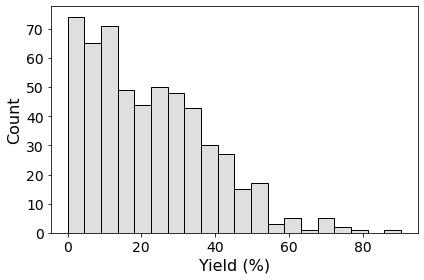

Data distribution for condition 87 (551 examples):

Average yield for this sub-dataset: 22%
Percentage of low-performing examples for these conditions (<10%): 29%


In [18]:
# Some information for this sub-dataset:
sub_data = data.loc[data["condition_id"] == 87]
plt.figure(figsize=(6, 4))
plt.hist(sub_data["yield"]*100, color=hist_color, bins=20, edgecolor="k")
plt.xlabel("Yield (%)")
plt.ylabel("Count")
plt.tick_params(axis='both', which='major')
plt.tight_layout()
plt.show()
print(f"Data distribution for condition 87 ({len(sub_data)} examples):\n")
print(f'Average yield for this sub-dataset: {round(sub_data["yield"].mean()*100)}%')
print(f'Percentage of low-performing examples for these conditions (<10%): {round(len(sub_data[sub_data["yield"] < 0.10])/len(sub_data)*100)}%')

Check for conditions with many (≥550) examples and a mediocre overall performance (35% ≤ average yield ≤ 45%):

In [19]:
for condition_id in data["condition_id"].unique():
    if len(data[data["condition_id"] == condition_id]) >= 550:
        if data[data["condition_id"] == condition_id]["yield"].mean() <= 0.45 and data[data["condition_id"] == condition_id]["yield"].mean() >= 0.35:
            print(f"This condition has more than 550 examples and an average yield between 35% and 45% percent: {condition_id}")

This condition has more than 550 examples and an average yield between 35% and 45% percent: 24


Visualize this condition with mediocre performance:

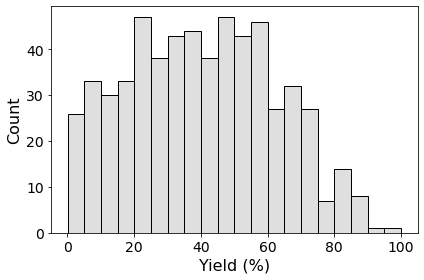

Data distribution for condition 24 (585 examples):
Average yield for this sub-dataset: 40%
Percentage of low-performing examples for these conditions (<10%): 10%


In [20]:
# Information for this sub-dataset
sub_data = data.loc[data["condition_id"] == 24]
plt.figure(figsize=(6, 4))
plt.hist(sub_data["yield"]*100, color=hist_color, bins=20, edgecolor="k")
plt.xlabel("Yield (%)")
plt.ylabel("Count")
plt.tick_params(axis='both', which='major')
plt.tight_layout()
plt.show()
print(f"Data distribution for condition 24 ({len(sub_data)} examples):")
print(f'Average yield for this sub-dataset: {round(sub_data["yield"].mean()*100)}%')
print(f'Percentage of low-performing examples for these conditions (<10%): {round(len(sub_data[sub_data["yield"] < 0.10])/len(sub_data)*100)}%')

There are reaction conditions in the dataset that give high, medium, and low performance and that all have many examples.

The three sub-datasets for these three condtions could be used to analyze the effect of the dataset distribution on the algorithm performance using a real-world example. While all three sub-datasets have many examples, it would be good if they could have the same exact product examples to make this analysis more meaningful.

Let's see how many examples are shared between these three sub-datasets and how the yield distribution looks like for that shared set of products.

There are 522 shared products among these three conditions.


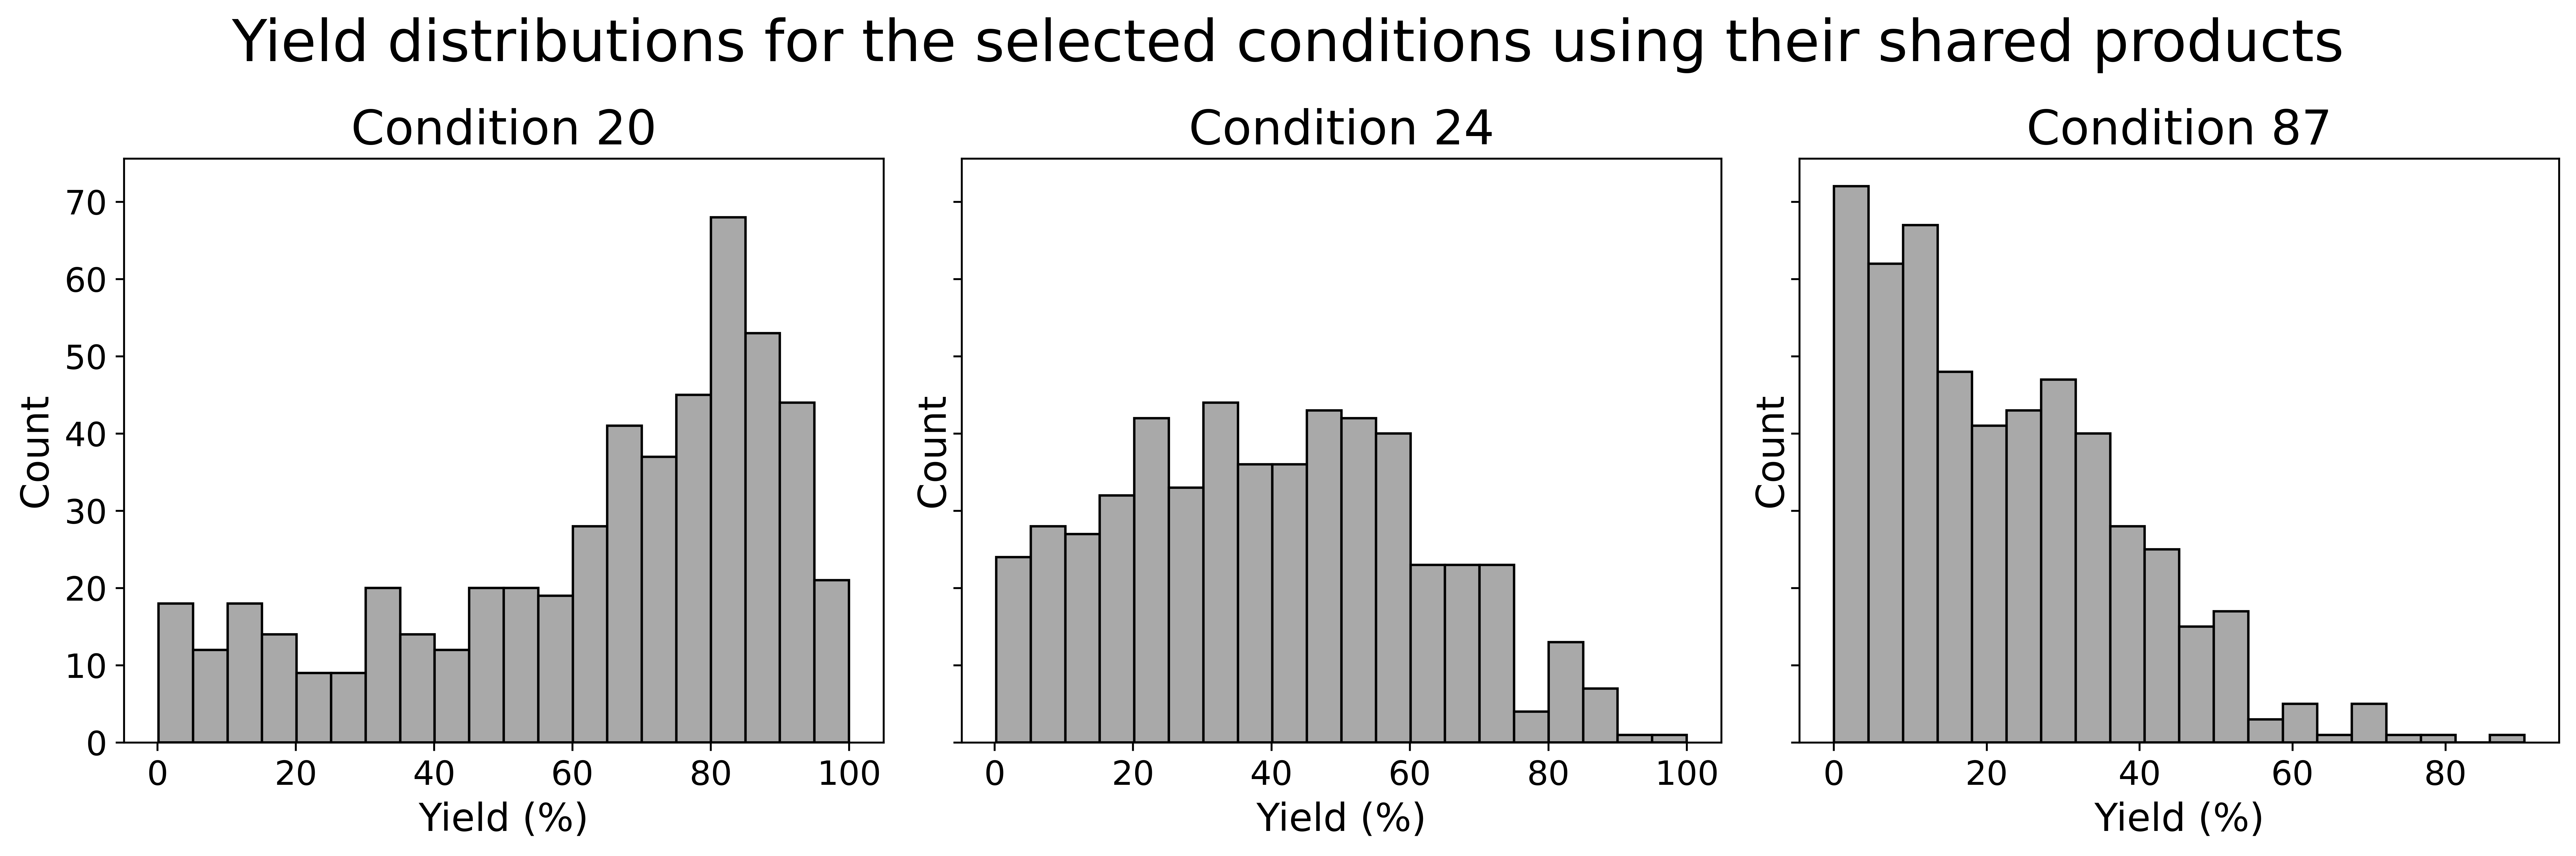

Average yield for these conditions:
Condition 20: 62.97%
Condition 24: 39.84%
Condition 87: 22.16%
Percentage of low-performing examples for these conditions (<10%):
Condition 20: 5%
Condition 24: 8%
Condition 87: 26%


In [21]:
# Define the reaction conditions of interest.
condition_ids = [20,24,87]
condition_data_shared_products = {}
# Get the shared products.
shared_data = data[data["condition_id"].isin(condition_ids)]
product_sets = shared_data.groupby("condition_id")["product_smiles"].apply(set)
shared_products = set.intersection(*product_sets)
print(f"There are {len(shared_products)} shared products among these three conditions.")

def condition_data(figsize=(15,5),show_labels=True):
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True, dpi=600)
    if show_labels:
        fig.suptitle("Yield distributions for the selected conditions using their shared products")

    for idx,cond_id in enumerate(condition_ids):
        cond_data = data.loc[data["condition_id"] == cond_id]  # get the data for the condtion
        condition_data_shared_products[cond_id] = cond_data[cond_data["product_smiles"].isin(shared_products)] # only keep the shared products
        # remove potential reaction duplicates by forming their average
        condition_data_shared_products[cond_id] = condition_data_shared_products[cond_id].groupby('product_smiles', as_index=False).agg({'yield': 'mean'})
        axes[idx].hist(condition_data_shared_products[cond_id]["yield"]*100, color=all_colors[6], bins=20, edgecolor="k")
        if show_labels:
            axes[idx].set_xlabel("Yield (%)")
            axes[idx].set_ylabel("Count")
            axes[idx].tick_params(axis='both', which='major')
            axes[idx].set_title(f"Condition {ids_top_cond[i]} ({len(sub_data)} examples)")
            axes[idx].set_title(f"Condition {cond_id}")
            axes[idx].set_xlabel("Yield (%)")
            axes[idx].set_ylabel("Count")
        else:
            axes[idx].set_xticks([])
            axes[idx].set_yticks([])
    plt.tight_layout()
    plt.show()

condition_data()

print("Average yield for these conditions:")
for id in condition_ids:
    print(f'Condition {id}: {round(condition_data_shared_products[id]["yield"].mean()*100,2)}%')
print("Percentage of low-performing examples for these conditions (<10%):")
for id in condition_ids:
    print(f'Condition {id}: {round(len(condition_data_shared_products[id][condition_data_shared_products[id]["yield"] < 0.10])/len(sub_data)*100)}%')

Reprint for manuscript

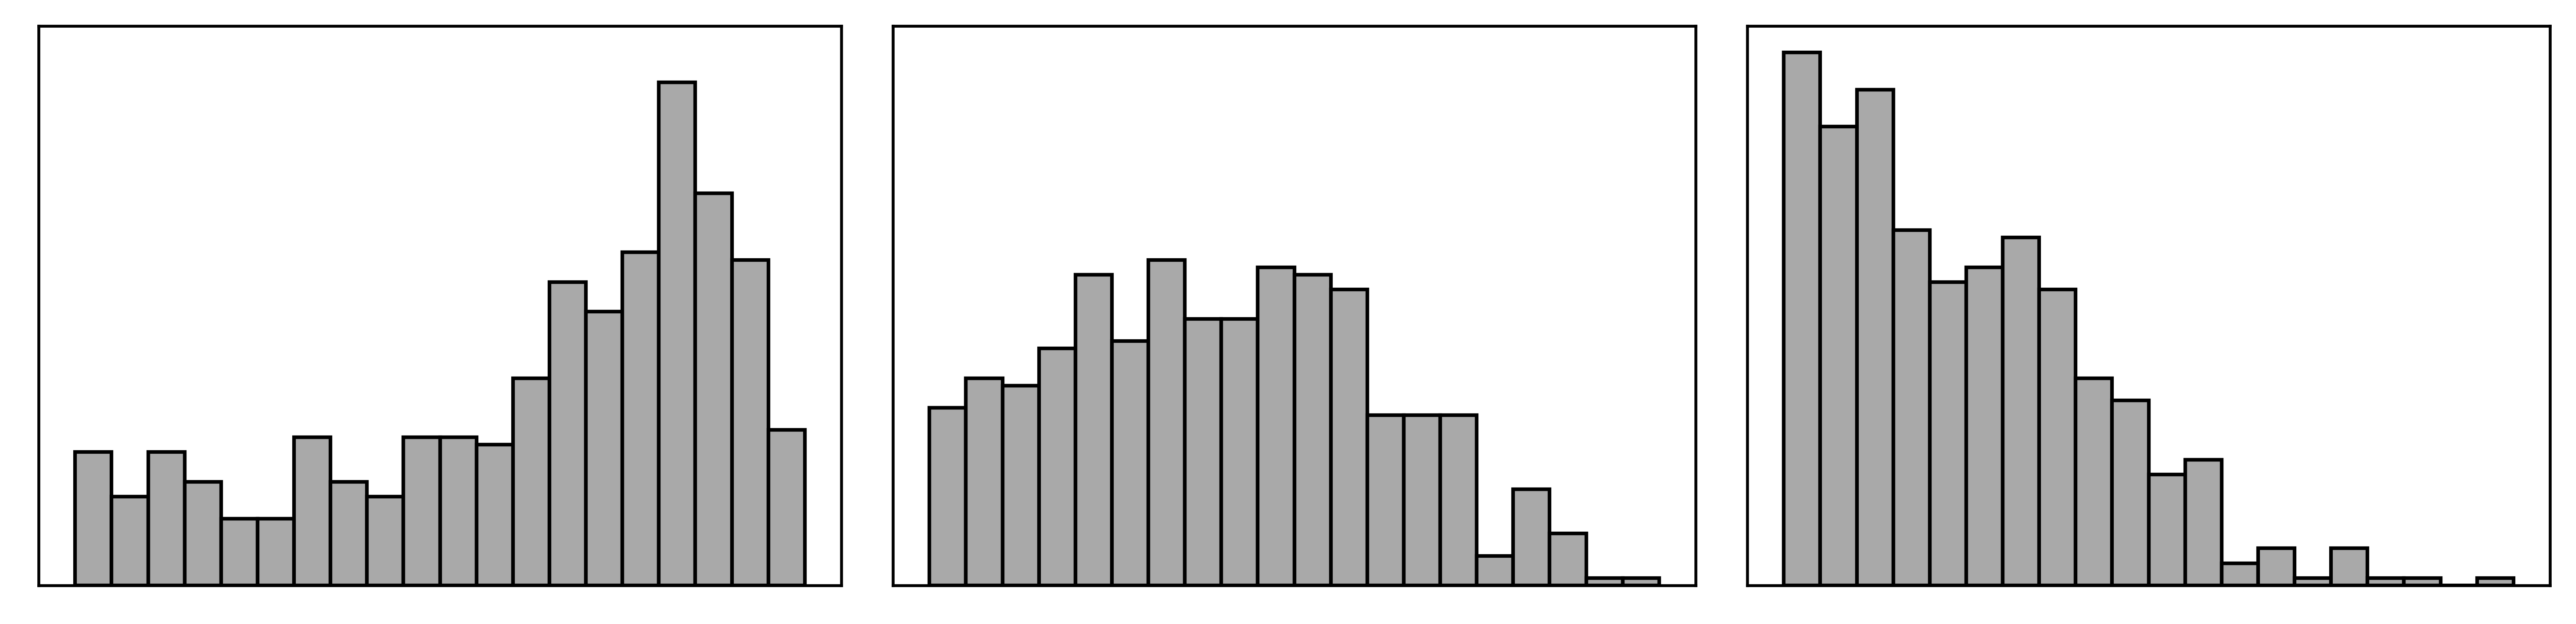

In [22]:
condition_data(figsize=(10,2.5),show_labels=False)

The sub-dataset distributions for all these subsets remain almost the same and the number of shared products is only a bit lower than the original number of products for these condition datasets (522 products), enabling us to use the subsets for the envisioned analysis of the dataset distribution.

In [23]:
# make a df for the shared products and the corresponding substrate combination
df_prods = pd.DataFrame(shared_products, columns = ["Products"])
# assign the substrate combination
for idx in df_prods.index:
    amine = data[data["product_smiles"] == df_prods.loc[idx,"Products"]]["sub_1_smiles"].unique()[0]
    acid = data[data["product_smiles"] == df_prods.loc[idx,"Products"]]["sub_2_smiles"].unique()[0]
    df_prods.loc[idx,"Combination"] = f"{amine}.{acid}"
df_prods.head(3)

,Products,Combination
0,Cc1ccc([N+](=O)[O-])cc1NC(=O)Cc1ccc2c(c1)OCO2,Cc1ccc([N+](=O)[O-])cc1N.O=C(O)Cc1ccc2c(c1)OCO2
1,COc1ccc(CC(=O)Nc2cc([N+](=O)[O-])ccc2C)cc1,Cc1ccc([N+](=O)[O-])cc1N.COc1ccc(CC(=O)O)cc1
2,COc1ccc(NC(=O)c2cc(Br)cnc2OC)cn1,COc1ccc(N)cn1.COc1ncc(Br)cc1C(=O)O


In [24]:
# save it
df_prods.to_csv(index = False, header = False,
                path_or_buf="./Datasets/0_Descriptor_Generation/amide_smiles_products_filtered.csv")

The datasets are visually fairly similar to the ArI optimization datasets. We therefore compared the datasets with a Kolmogorov-Smirnov test to see if the distribution shapes are the same.

In [25]:
def normalize(data):
    min_val = data.min()
    max_val = data.max()
    return data.apply(lambda x: (x- min_val) / (max_val - min_val))

print("Kolmogorov-Smirnov analysis for the amide datasets compared to the ArI datasets with similar distributions:\n")
for dset in ["high","medium","low"]:
    print(f"{dset} datasets:")
    df_ari = pd.read_csv(f"./../../dataset_ArI/0_Data/Datasets/Datasets_Hyperpar_Opt/data-{dset}.csv",index_col=0)

    df_amide = pd.read_csv(f"./../Amide_data/Datasets/amide_dset_dft_subs_{dset}-yielding.csv",index_col=0)

    statistic, p_value = ks_2samp(normalize(df_ari["rate"]), normalize(df_amide["yield"]))

    print("KS statistic:", statistic)
    print("p value:", p_value)
    print("")

print("Note: The data was normalized to only compare the distribution shape.")


Kolmogorov-Smirnov analysis for the amide datasets compared to the ArI datasets with similar distributions:

high datasets:
KS statistic: 0.2033325869532766
p value: 1.0306049046295826e-10

medium datasets:
KS statistic: 0.2848700953659423
p value: 2.6142725589120627e-30

low datasets:
KS statistic: 0.13989146801437155
p value: 2.226627701137857e-06

Note: The data was normalized to only compare the distribution shape.


The Kolmogorov-Smirnov tests indicate the distribution shapes for the amide and ArI datasets are not the same as the null hypothesis is rejected (p < 0.05 for all datasets.)

Extending on this analysis, we also extracted all amide coupling subsets that have unique distributions. By testing ScopeBO on all these datasets, we can get a holistic view of the algorithm performance when exposed to different scenarios.

In order to find the condition subsets with unique distributions, we carry out pairwise Kolmogorov-Smirnov tests for all condition combinations (after normalizing the distributions to only look at the distribution shape). The p values are then corrected with the false discovery rate (FDR) correction using the Benjamini-Hochberg method.

Pairwise KS test p-values calculated.
Removing condition 1 with 1 examples.
Number of pairwise comparisons: 4465
P-values corrected for multiple comparisons with the FDR Benjamini-Hochberg procedure.


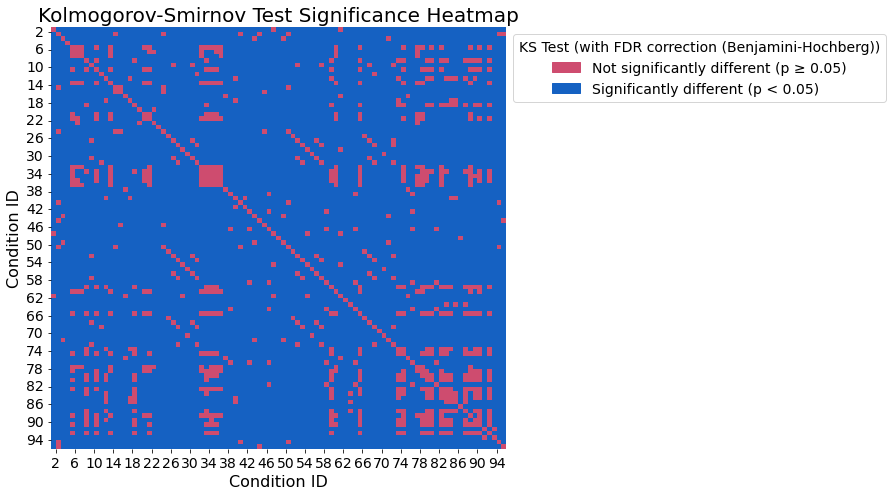

In [26]:
def normalize(data):
    min_val = data.min()
    max_val = data.max()
    return data.apply(lambda x: (x- min_val) / (max_val - min_val))

def KS_test(i, j):
    _, p_value = ks_2samp(normalize(data[data["condition_id"] == i]["yield"]), 
                                  normalize(data[data["condition_id"] == j]["yield"]))
    return p_value

# calculate the pairwise KS test p-values for all condition combinations
ks_comp = pd.DataFrame(np.nan, index = range(1,97,1), columns = range(1,97,1))
for i in range(1,97,1):
    for j in range(1,97,1):
        ks_comp.loc[i, j] = KS_test(i, j)
print("Pairwise KS test p-values calculated.")

# only keep conditions that have at least 200 examples
pruned = []
for id in ks_comp.index:
    if len(data.loc[data["condition_id"] == id]) < 200:
        print(f"Removing condition {id} with {len(data.loc[data['condition_id'] == id])} examples.")
        pruned.append(id)
for id in pruned:
    ks_comp.drop(index=id, columns=id,inplace=True)


# get all p-values in a 1D array (just the upper triangle without the diagonal to avoid duplicates)
# Boolean mask for upper triangle, excluding diagonal
mask = np.triu(np.ones(ks_comp.shape, dtype=bool), k=1)  # k=1 excludes the diagonal (self-comparisons)
# stack p-values
pvals = ks_comp.where(mask).stack()
print("Number of pairwise comparisons:", len(pvals))

# correct for multiple comparisons with the FDR Benjamini-Hochberg procedure
_, pvals_corr, _, _ = multipletests(pvals.values, method="fdr_bh")
pvals_corr = pd.Series(pvals_corr, index=pvals.index)
print("P-values corrected for multiple comparisons with the FDR Benjamini-Hochberg procedure.")

# Assign corrected p-values back
ks_comp_corr = ks_comp.copy()
ks_comp_corr.update(pvals_corr.unstack())

# Mirror to lower triangle
ks_comp_corr = ks_comp_corr.combine_first(ks_comp_corr.T)

# Set the self-comparison p-values to 1
np.fill_diagonal(ks_comp_corr.values, 1.0)

# heatmap of the corrected KS test p-values (significant values (<0.05) are blue, rest rest)
ks_comp_bin = ks_comp_corr.applymap(lambda x: 0 if x > 0.05 else 1).copy()
plt.figure(figsize=(12.5, 7))
ax = sns.heatmap(
    ks_comp_bin,
    cmap=all_colors[:2],
    cbar=False)
legend_elements = [
    mpatches.Patch(color=all_colors[0], label='Not significantly different (p ≥ 0.05)'),
    mpatches.Patch(color=all_colors[1], label='Significantly different (p < 0.05)')]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    title='KS Test (with FDR correction (Benjamini-Hochberg))')

# Desired tick labels
tick_labels = list(range(2, ks_comp_bin.shape[0] + 1, 4))

# Positions in the heatmap (center of cells)
tick_positions = [i - 1 for i in tick_labels]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=0)

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels, rotation=0)

plt.title("Kolmogorov-Smirnov Test Significance Heatmap")
plt.xlabel("Condition ID")
plt.ylabel("Condition ID")
plt.tight_layout()
plt.show()

Based on these p values, we can search for the maximum subsets of condition datasets that are all significantly different from one another.

In [27]:
# convert KS data into a graph representation to find the maximum subset of conditions that are statistically different from each other
G = nx.Graph()
# Add nodes for each condition
G.add_nodes_from(ks_comp_bin.index)

# Add edges where ks_comp_bin == 1 (meaning significant difference)
for i in ks_comp_bin.index:
    for j in ks_comp_bin.columns:
        if i < j and ks_comp_bin.loc[i, j] == 1:  # avoid double counting
            G.add_edge(i, j)

In [28]:
# approximate the largest clique (maximally connected subgraph --> meaning all cond. are significantly different from each other)
max_clique = nx.algorithms.approximation.max_clique(G)
print("Number of condition sub-datasets that have statistically different yield distribution shapes:", len(max_clique))
print("Conditions IDs:", max_clique)

Number of condition sub-datasets that have statistically different yield distribution shapes: 28
Conditions IDs: {2, 3, 4, 5, 8, 9, 10, 12, 13, 16, 17, 20, 21, 24, 26, 28, 29, 30, 39, 42, 43, 49, 57, 63, 64, 70, 82, 94}


In [29]:
print("Pruning to datasets that have at least 15% average yield.\n")
pruned = []
for id in max_clique:
    av_yield = data.loc[data["condition_id"] == id]["yield"].mean()*100
    if av_yield < 15:
        print(f"Removing condition {id} with {round(av_yield)}% average yield.")
        pruned.append(id)
for id in pruned:
    max_clique.remove(id)

print(f"\nAfter pruning by average yield, there are {len(max_clique)} unique datasets left.")

Pruning to datasets that have at least 15% average yield.

Removing condition 2 with 6% average yield.
Removing condition 4 with 2% average yield.
Removing condition 16 with 12% average yield.
Removing condition 17 with 11% average yield.
Removing condition 29 with 6% average yield.
Removing condition 39 with 8% average yield.
Removing condition 43 with 14% average yield.
Removing condition 82 with 10% average yield.

After pruning by average yield, there are 20 unique datasets left.


In [30]:
type(max_clique)

set

Safety check - plotting the KS heatmap again with only the pruned unique datasets:


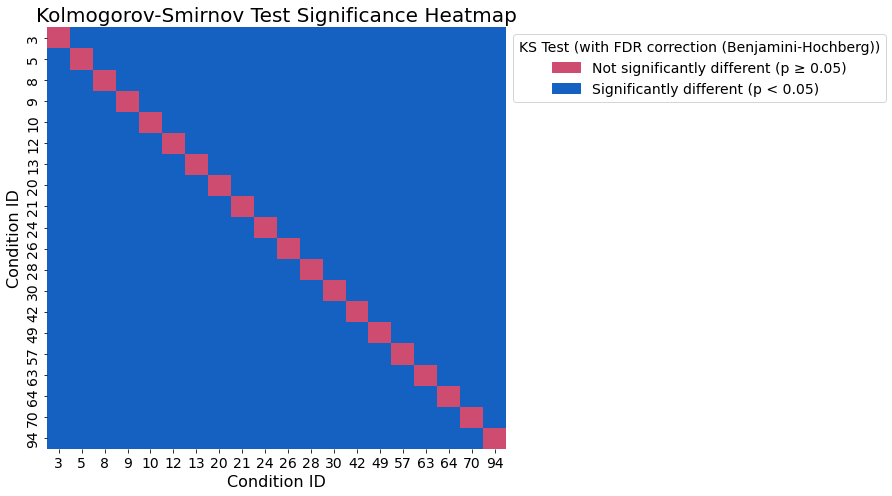

In [31]:
print("Safety check - plotting the KS heatmap again with only the pruned unique datasets:")

plt.figure(figsize=(12.5, 7))
ax = sns.heatmap(
    ks_comp_bin[max_clique].loc[max_clique],
    cmap=all_colors[:2],
    cbar=False)
legend_elements = [
    mpatches.Patch(color=all_colors[0], label='Not significantly different (p ≥ 0.05)'),
    mpatches.Patch(color=all_colors[1], label='Significantly different (p < 0.05)')]
ax.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1, 1),
    title='KS Test (with FDR correction (Benjamini-Hochberg))')
plt.title("Kolmogorov-Smirnov Test Significance Heatmap")
plt.xlabel("Condition ID")
plt.ylabel("Condition ID")
plt.tight_layout()
plt.show()

Distribution of yields for the unique datasets:


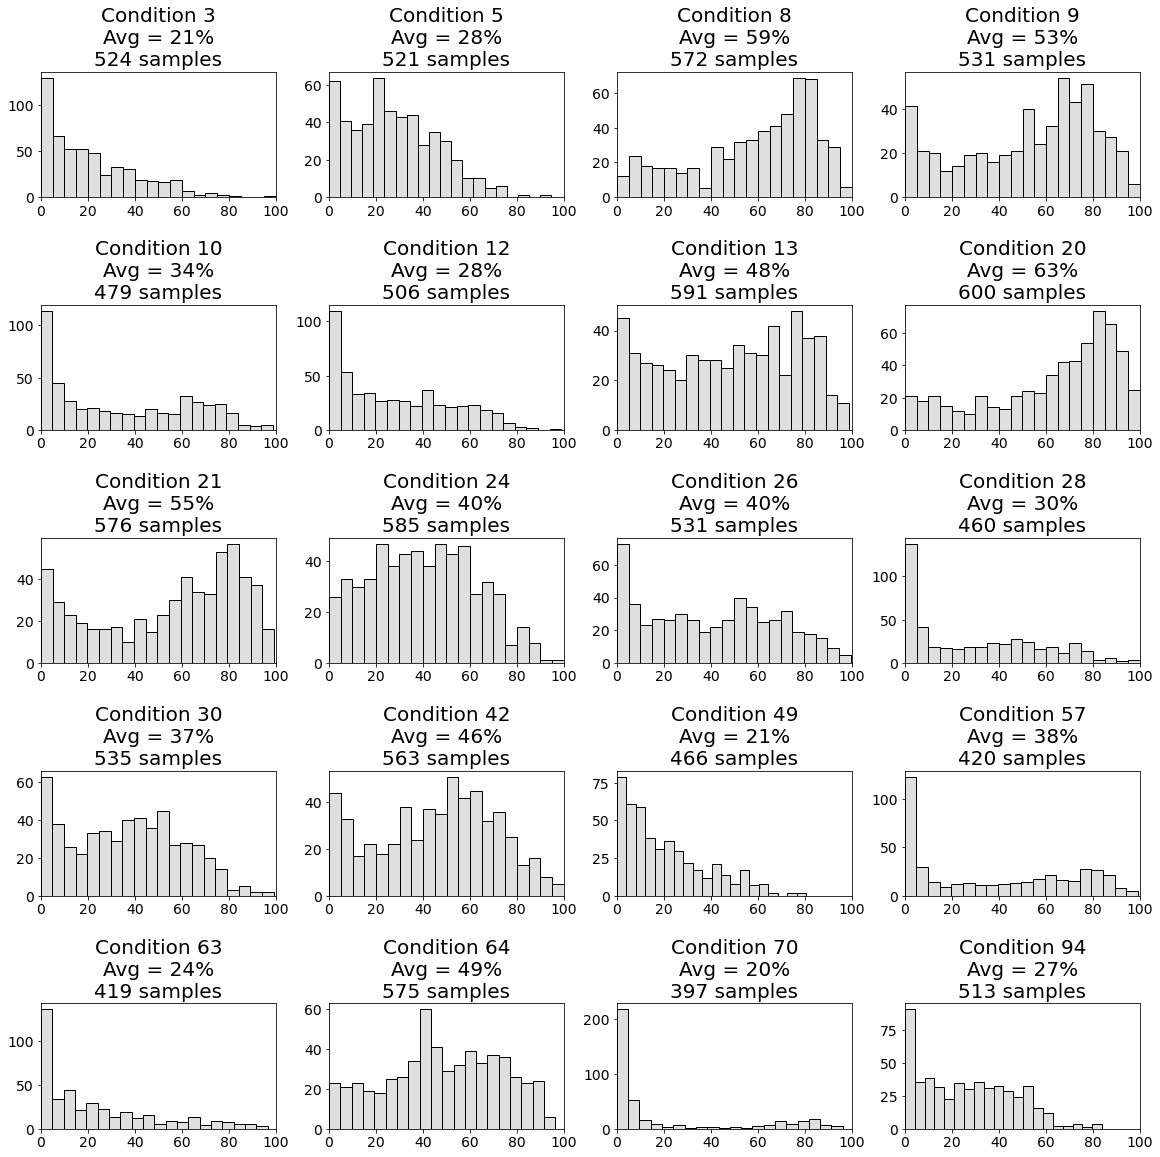

In [32]:
print("Distribution of yields for the unique datasets:")

rows, cols = 6, 4
fig, axes = plt.subplots(rows, cols, figsize=(16, 18), gridspec_kw={"hspace": 0.1}, constrained_layout = True)
axes = axes.flatten()

n = len(max_clique)

for i, cond_id in enumerate(max_clique):
    ax = axes[i]
    sub_data = data.loc[data["condition_id"] == cond_id]

    ax.hist(sub_data["yield"] * 100, bins=20, color=hist_color, edgecolor="k")
    ax.set_xlim(0, 100)
    ax.set_title(f"Condition {cond_id}\nAvg = {round(sub_data['yield'].mean()*100)}%\n{len(sub_data)} samples")

# Hide unused subplot
for j in range(n, rows*cols):
    axes[j].set_visible(False)

plt.show()


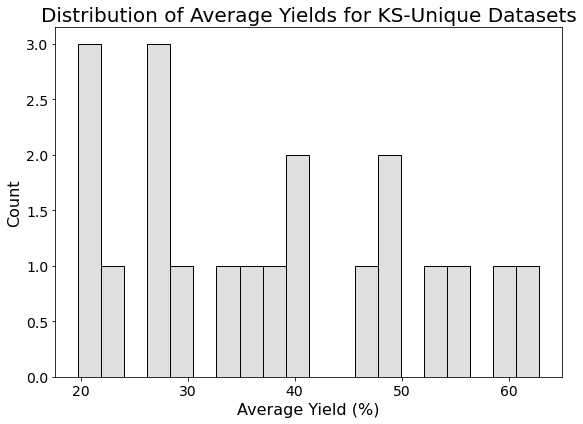

In [33]:
# plot the distribution of average yields for the unique datasets
avg_yields = [data.loc[data["condition_id"] == cond_id]["yield"].mean()*100 for cond_id in max_clique]
plt.figure(figsize=(8, 6))
plt.hist(avg_yields, bins=20, color=hist_color, edgecolor="k")
plt.xlabel("Average Yield (%)")
plt.ylabel("Count")
plt.title("Distribution of Average Yields for KS-Unique Datasets")
plt.tight_layout()
plt.show()

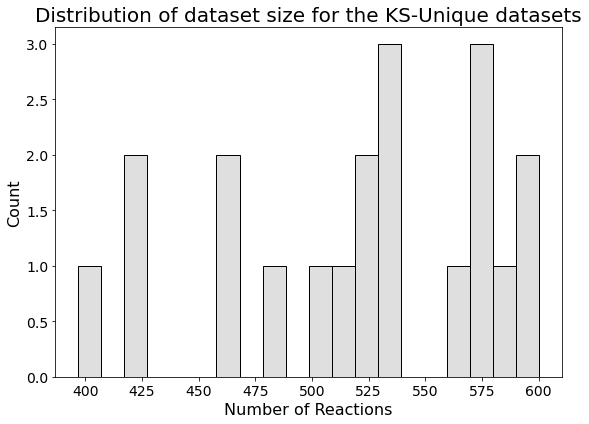

In [34]:
# plot the distribution of data points per unique dataset
data_points = [len(data.loc[data["condition_id"] == cond_id]) for cond_id in max_clique]
plt.figure(figsize=(8, 6))
plt.hist(data_points, bins=20, color=hist_color, edgecolor="k")
plt.xlabel("Number of Reactions")
plt.ylabel("Count")
plt.title("Distribution of dataset size for the KS-Unique datasets")
plt.tight_layout()
plt.show()

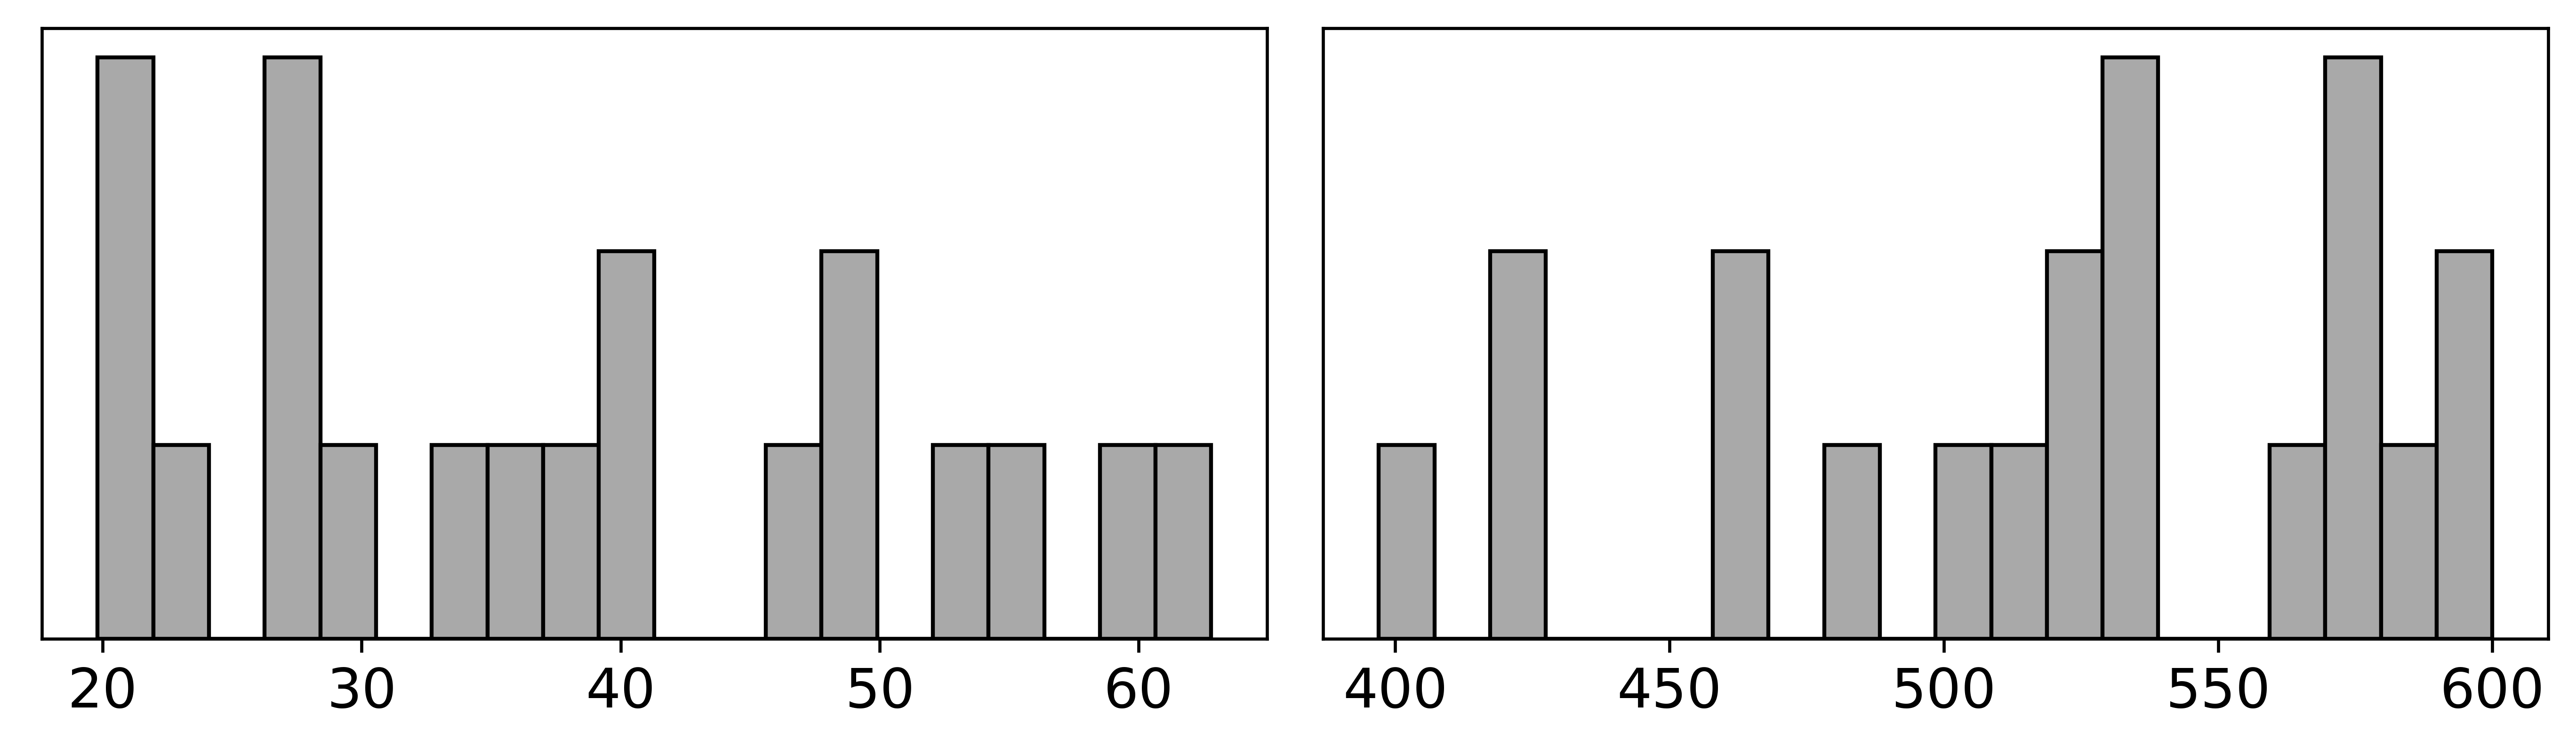

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(9.26,2.747), sharey=True, dpi=600)
for idx,data in enumerate([avg_yields,data_points]):
    axes[idx].hist(data, color=all_colors[6], bins=20, edgecolor="k")
    axes[idx].set_yticks([])
plt.tight_layout()
plt.show()

There are 20 condition datasets with unique distributions within the 96 conditions that are a sufficient size (>200 samples) and performance (>15% average yield). By evaluating our algorithm on all these datasets, we can test the generality of our strategy.

In [35]:
# save the list of unique datasets
pd.DataFrame(max_clique).to_csv("./Datasets/KS-unique_Datasets/list_of_KS-unique_conds.csv",index=False,header=False)